# RL Budget Energy v12 — MultiDiscrete PPO (FIXED)
**Perubahan utama dari v11:**
- Action space: `MultiDiscrete([2,2,2,2,2])` — 5 keputusan independen per perangkat
- Actor: shared trunk + 5 head terpisah (AC, Magicom, WH, TV, Laptop)
- Reward: per-device shaping — penalti aksi sia-sia lebih akurat
- Agent bisa **kombinasi** beberapa aksi sekaligus dalam 1 timestep
- Arsitektur lebih bersih: semua magic number ke KONFIGURASI

**🐛 BUG FIX (v12 → v12-fixed):**
- `_device_flags()` fallback: operator `>=` diganti **range check** (`DEVICE_WATT_MIN <= d <= DEVICE_WATT_MAX`)
- Mencegah overlap flag yang menyebabkan reward distortion (false positive `R_CORRECT_HIT`)

**Prasyarat:** Jalankan `SARIMAX_v9` Cell 0–13 dulu untuk menghasilkan `sarimax_model_for_rl.pkl`

In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 0 — KONFIGURASI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Path ────────────────────────────
JSON_PATH  = "/content/drive/MyDrive/data/test-reading-the-pzem-default-rtdb-export (10).json"
PKL_PATH   = "/content/drive/MyDrive/data/sarimax_model_for_rl.pkl"
MODEL_SAVE = "/content/drive/MyDrive/data/actor_rl_v12.pt"

# ── Rentang data ───────────────────────
START_DATE = "2026-03-05"
END_DATE   = "2026-04-03"

# ── Konstanta energi ────────────────────
TARIF_KWH      = 1352.0
DEFAULT_BUDGET = 62487.0
TIMEZONE       = "Asia/Jakarta"

# ── Device config (MultiDiscrete) ──────────
DEVICE_NAMES     = ["AC", "Magicom", "WaterHeater", "TV", "Laptop"]
DEVICE_REDUCTION = [0.30,  0.10,      0.20,          0.05,  0.05  ]  # reduksi daya saat action=1
DEVICE_WATT_MIN  = [314,   280,       210,           26,    12    ]
DEVICE_WATT_MAX  = [9999,  313,       279,           60,    25    ]
N_DEVICES        = len(DEVICE_NAMES)   # 5

# ── Reward weights ───────────────────────
R_WASTED_ACTION   = -0.03
R_CORRECT_HIT     =  0.08
R_IDLE_OVERBUDGET = -0.10
R_OVER_ACT        = -0.04
R_TEMP_BONUS      =  0.05
R_PEAK_BONUS      =  0.03
R_STABILITY       = -0.005

# ── Hyperparameter PPO ───────────────────
OBS_DIM      = 16
HIDDEN_DIM   = 128
LR_ACTOR     = 3e-4
LR_CRITIC    = 1e-3
GAMMA        = 0.99
LAMBDA_GAE   = 0.95
CLIP_EPS     = 0.2
ENTROPY_COEF = 0.03
N_STEPS      = 2048
BATCH_SIZE   = 512
N_EPOCHS     = 10
TOTAL_TS     = 500_000
USE_LR_SCHEDULER = True

# ── Kalibrasi sensor ───────────────────
CAL_CURRENT = 1.018
CAL_VOLTAGE = 1.000

# ── Normalisasi state ───────────────────
DAYA_MAX = 600.0; SUHU_MAX = 60.0; JAM_MAX = 23.0
DOW_MAX  = 6.0;   DAYS_MAX = 31.0; WATT_MAX = 600.0

print("✅ Konfigurasi v12 dimuat")

✅ Konfigurasi v12 dimuat


## Cell 1 — Install & Import

In [23]:
!pip install statsmodels torch pytz --quiet

import os, json, warnings, calendar, traceback
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytz, torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
import joblib

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TZ     = pytz.timezone(TIMEZONE)

C = {"blue":"#0969da","amber":"#b45309","green":"#15803d",
     "red":"#dc2626","purple":"#7c3aed","teal":"#0d9488","gray":"#57606a"}
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","text.color":"#1f2328",
    "axes.edgecolor":C["gray"],"grid.color":"#d0d7de","grid.linewidth":0.6,
    "font.family":"monospace","axes.spines.top":False,"axes.spines.right":False,
})
OUT = Path("rl_v12_output"); OUT.mkdir(exist_ok=True)
print(f"✅ Import selesai | device={DEVICE}")


✅ Import selesai | device=cpu


## Cell 2 — Load Data Firebase (JSON) + Mount Drive

In [24]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

with open(JSON_PATH, "r", encoding="utf-8") as _f:
    RAW_DATA = json.load(_f)

print(f"✅ Data dimuat: {JSON_PATH}")
print(f"   Top-level keys : {list(RAW_DATA.keys())}")
print(f"   history        : {len(RAW_DATA.get('history',{}))} record")
print(f"   rekap_harian   : {len(RAW_DATA.get('rekap_harian',{}).get('history',{}))} hari")
print(f"   log_konfirmasi : {len(RAW_DATA.get('log_konfirmasi',{}))} entri")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data dimuat: /content/drive/MyDrive/data/test-reading-the-pzem-default-rtdb-export (10).json
   Top-level keys : ['Evaluasi_Model_SARIMAX', 'Hasil_AI', 'Kwh_Jam', 'Monitoring', 'dashboard_info', 'history', 'log_konfirmasi', 'rekap_harian', 'user_confirmation', 'user_preferences']
   history        : 60180 record
   rekap_harian   : 68 hari
   log_konfirmasi : 242 entri


## Cell 3 — SARIMAX Forecast Map

In [25]:
# ── Cell 3a — SARIMAX_FORECAST_MAP (FIXED v2) ────────────────────────────────
# FIX: OOS dates sekarang pakai rolling median dari rekap_harian (bukan
#      forecast jauh ke depan yang kolaps ke mean 1.113 kWh)
import datetime as _dtm
print("🔄 [3] Membangun SARIMAX_FORECAST_MAP...")

_PUSH = "-0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ_abcdefghijklmnopqrstuvwxyz"
def _k2ms(k):
    try:
        t = 0
        for c in str(k)[:8]: t = t*64 + _PUSH.index(c)
        return t
    except: return None

_recs = [dict(v, _key=k) for k, v in RAW_DATA["history"].items() if isinstance(v, dict)]
_df   = pd.DataFrame(_recs)
for _c in ["Daya","Suhu","Arus","Tegangan"]:
    if _c in _df.columns: _df[_c] = pd.to_numeric(_df[_c], errors="coerce")
_wk  = pd.to_numeric(_df.get("waktu", pd.Series([None]*len(_df))), errors="coerce")
_fbk = _df["_key"].map(_k2ms) if "_key" in _df.columns else pd.Series([None]*len(_df))
_df["dt"] = (pd.to_datetime(_wk.where(_wk.notna(), _fbk), unit="ms", errors="coerce")
             .dt.tz_localize("UTC").dt.tz_convert(TIMEZONE))
_df = _df.dropna(subset=["dt","Daya"]).sort_values("dt").set_index("dt")
_S = pd.Timestamp(START_DATE, tz=TIMEZONE)
_E = pd.Timestamp.now(tz=TIMEZONE) if END_DATE is None else pd.Timestamp(END_DATE, tz=TIMEZONE)
_df = _df[(_df.index >= _S) & (_df.index <= _E)]
_dfh = _df[["Daya"]].resample("1h").median().interpolate("time").dropna()
_mean_daya = float(_dfh["Daya"].mean())
print(f"   Hourly: {len(_dfh)} jam | mean={_mean_daya:.1f}W")

if not os.path.exists(PKL_PATH):
    raise FileNotFoundError(f" {PKL_PATH} tidak ada → jalankan SARIMAX v9 Cell 13 dulu")
_b = joblib.load(PKL_PATH)
_res, _lmbda, _shift = _b["model"], _b["lmbda"], _b.get("shift", 0.0)
_exog_cols = _b["exog_cols"]
_te_date   = _dtm.date.fromisoformat(str(_b["train_end"])[:10])
print(f"   SARIMA{_b['order']}x{_b['seasonal_order']} λ={_lmbda:.4f} train_end={_te_date}")

def _bc_inv(x):
    x = np.asarray(x, dtype=float).flatten()
    if abs(_lmbda) < 1e-8: return np.clip(np.exp(x) - _shift, 0, None)
    inside = _lmbda * x + 1.0
    return np.clip(np.where(inside > 0, inside**(1.0/_lmbda), 0.0) - _shift, 0, None)

# Rekap harian dari Firebase
_rh_raw = RAW_DATA.get("rekap_harian", {}).get("history", {})
_kwh_d  = {}
for _tgl, _v in _rh_raw.items():
    if isinstance(_v, dict):
        try: _kwh_d[pd.Timestamp(_tgl).date()] = float(_v.get("penggunaan_kwh", 0) or 0)
        except: pass

_udates    = sorted(set(_dfh.index.date))
_tr_dates  = [d for d in _udates if d <= _te_date]
_oos_dates = [d for d in _udates if d >  _te_date]
_known_sorted = sorted(_kwh_d.keys())   # untuk rolling lookup

def _make_exog(dates):
    rows = []
    for _d in dates:
        _ts  = pd.Timestamp(_d); _dow = _ts.dayofweek; _mon = _ts.month
        _kwh = _kwh_d.get(_d, 0.5)
        rows.append([float(_kwh >= 0.1), float(_dow >= 5),
                     np.sin(2*np.pi*_dow/7), np.cos(2*np.pi*_dow/7),
                     np.sin(2*np.pi*_mon/12), np.cos(2*np.pi*_mon/12)])
    return np.array(rows, dtype=float)

_date_to_watt = {}

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # ── In-sample: pakai predict() dari model (akurat) ──────────────────
        if _tr_dates:
            _fc_tr  = np.array(_res.predict(start=0, end=len(_tr_dates)-1)).flatten()
            _kwh_tr = _bc_inv(_fc_tr)
            for _i, _d in enumerate(_tr_dates):
                _date_to_watt[_d] = float(max(_kwh_tr[_i], 0) * 1000.0 / 24.0)
            print(f"   In-sample  : {len(_tr_dates)} hari → rata-rata {np.mean(_kwh_tr):.3f} kWh/hari")

        # ── OOS FIX: rolling median 7 hari dari rekap_harian ────────────────
        # Kenapa? forecast() 19–71 hari ke depan → ARIMA kolaps ke mean (flat)
        # Rolling median dari data aktual → mengikuti tren terkini (MAPE ~20%)
        if _oos_dates:
            _oos_kwh_list = []
            for _d in _oos_dates:
                # Ambil max 7 hari terakhir yang LEBIH KECIL dari tanggal ini
                _recent = [_kwh_d[k] for k in _known_sorted if k < _d][-7:]
                if len(_recent) >= 1:
                    _kwh_pred = float(np.median(_recent))
                else:
                    # Tidak ada data → pakai mean training
                    _tr_mean = np.mean(list(_kwh_d.values())) if _kwh_d else _mean_daya*24/1000
                    _kwh_pred = float(_tr_mean)
                _oos_kwh_list.append(_kwh_pred)
                _date_to_watt[_d] = max(_kwh_pred, 0) * 1000.0 / 24.0

            _oos_arr = np.array(_oos_kwh_list)
            print(f"   OOS rolling: {len(_oos_dates)} hari → rata-rata {_oos_arr.mean():.3f} kWh/hari")
            print(f"   OOS range  : {_oos_arr.min():.3f} – {_oos_arr.max():.3f} kWh/hari")
            print(f"   (sebelumnya: flat 1.113 kWh untuk semua OOS)")

except Exception as _err:
    traceback.print_exc()
    print(f"   ⚠️ Error → fallback mean_daya={_mean_daya:.1f}W")
    for _d in _udates: _date_to_watt[_d] = _mean_daya

# Build per-jam map
_fc_all = np.array([_date_to_watt.get(_ts.date(), _mean_daya) for _ts in _dfh.index])
SARIMAX_FORECAST_MAP = {
    _ts.strftime("%Y-%m-%d %H"): float(_fc_all[_j])
    for _j, _ts in enumerate(_dfh.index)
}

_nz = sum(1 for v in SARIMAX_FORECAST_MAP.values() if v > 0)
_unique = len(set(round(v,2) for v in SARIMAX_FORECAST_MAP.values()))
print(f"   MAP: {len(SARIMAX_FORECAST_MAP)} keys | {_nz} non-zero | {_unique} nilai unik")
if _unique <= 2:
    print("   ⚠️  PERINGATAN: prediksi masih hampir flat — cek rekap_harian.history")
else:
    print("   ✅ Prediksi bervariasi — rolling median berhasil")
del _recs, _df
print("✅ SARIMAX_FORECAST_MAP siap")


🔄 [3] Membangun SARIMAX_FORECAST_MAP...
   Hourly: 696 jam | mean=46.4W
   SARIMA(0, 1, 2)x(0, 0, 0, 7) λ=0.5673 train_end=2026-03-25
   In-sample  : 21 hari → rata-rata 1.446 kWh/hari
   OOS rolling: 8 hari → rata-rata 1.712 kWh/hari
   OOS range  : 1.633 – 1.771 kWh/hari
   (sebelumnya: flat 1.113 kWh untuk semua OOS)
   MAP: 696 keys | 696 non-zero | 26 nilai unik
   ✅ Prediksi bervariasi — rolling median berhasil
✅ SARIMAX_FORECAST_MAP siap


## Cell 4 — parse_rows() Helper

In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3b — parse_rows() FIXED v2
# FIX: log_konfirmasi field names mismatch
#   Firebase menyimpan: "AC","Magicom","Waterheater","TV","Laptop"
#   Sebelumnya kode mencari: "ac","magicom","wh","tv","laptop" → SEMUA GAGAL
#   Akibat: 130 entri konfirmasi tidak terbaca → WH sering salah aktif
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

_PUSH2 = "-0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ_abcdefghijklmnopqrstuvwxyz"
def _key_to_ms(k):
    try:
        t = 0
        for c in str(k)[:8]: t = t*64 + _PUSH2.index(c)
        return t
    except: return None

def _get_conf_field(v: dict, *keys, default=0) -> int:
    """Coba semua varian nama field (Firebase tidak konsisten case)."""
    for k in keys:
        val = v.get(k)
        if val is not None:
            return int(bool(val))
    return default

def parse_rows(raw: dict, max_rows: int = 100_000) -> list:
    history = raw.get("history", {})
    lk      = raw.get("log_konfirmasi", {})

    # ── Build konfirmasi lookup ──────────────────────────────────────────────
    # FIX: handle kedua format Firebase ("AC" kapital DAN "ac" lowercase)
    conf_map = {}
    _parsed_ok = 0
    for _k, _v in lk.items():
        if not isinstance(_v, dict): continue
        _ts = _v.get("timestamp") or _v.get("waktu")
        if _ts is None: continue
        try:
            _dt  = pd.Timestamp(int(_ts), unit="ms", tz="UTC").tz_convert(TIMEZONE)
            _key = _dt.strftime("%Y-%m-%d %H")
            conf_map[_key] = {
                # FIX: coba "AC" dulu (Firebase format), fallback ke "ac"
                "ac":      _get_conf_field(_v, "AC",          "ac"),
                "magicom": _get_conf_field(_v, "Magicom",     "magicom",  "MAGICOM"),
                "wh":      _get_conf_field(_v, "Waterheater", "WaterHeater", "wh", "WH"),
                "tv":      _get_conf_field(_v, "TV",          "tv"),
                "laptop":  _get_conf_field(_v, "Laptop",      "laptop",   "LAPTOP"),
            }
            _parsed_ok += 1
        except: pass
    print(f"   log_konfirmasi: {_parsed_ok}/{len(lk)} entri berhasil di-parse")
    if _parsed_ok == 0 and len(lk) > 0:
        # Debug: tampilkan contoh field names yang ada
        _sample = next(v for v in lk.values() if isinstance(v, dict))
        print(f"   ⚠️  Contoh field di Firebase: {list(_sample.keys())}")
        print(f"   → Sesuaikan _get_conf_field() dengan field names di atas")

    rows = []
    recs = [(k, v) for k, v in history.items() if isinstance(v, dict)]
    recs.sort(key=lambda x: _key_to_ms(x[0]) or 0)

    days_in_month = 30
    _S = pd.Timestamp(START_DATE, tz=TIMEZONE)
    _E = pd.Timestamp(END_DATE,   tz=TIMEZONE) if END_DATE else pd.Timestamp.now(tz=TIMEZONE)

    for _k, _v in recs[:max_rows]:
        try:
            _wk = _v.get("waktu")
            _ms = int(_wk) if _wk is not None else _key_to_ms(_k)
            if _ms is None: continue
            _dt  = pd.Timestamp(_ms, unit="ms", tz="UTC").tz_convert(TIMEZONE)
            if not (_S <= _dt <= _E): continue

            daya = float(_v.get("Daya", 0) or 0) * CAL_CURRENT
            suhu = float(_v.get("Suhu", 25) or 25)
            arus = float(_v.get("Arus", 0) or 0) * CAL_CURRENT
            teg  = float(_v.get("Tegangan", 220) or 220) * CAL_VOLTAGE

            jam       = float(_dt.hour)
            dow       = float(_dt.dayofweek)
            is_we     = float(dow >= 5)
            day_prog  = float(_dt.day / days_in_month)
            days_rem  = float(days_in_month - _dt.day)

            _hk    = _dt.strftime("%Y-%m-%d %H")
            pred_w = SARIMAX_FORECAST_MAP.get(_hk, 0.0)

            conf = conf_map.get(_hk, None)
            rows.append(TrainRow(
                daya=daya, suhu=suhu, arus=arus, tegangan=teg,
                jam=jam, day_of_week=dow, is_weekend=is_we,
                day_progress=day_prog, days_remaining=days_rem,
                sarimax_pred=pred_w,
                conf_ac      = conf["ac"]      if conf else -1,
                conf_magicom = conf["magicom"] if conf else -1,
                conf_wh      = conf["wh"]      if conf else -1,
                conf_tv      = conf["tv"]      if conf else -1,
                conf_laptop  = conf["laptop"]  if conf else -1,
            ))
        except: pass

    _n_conf = sum(1 for r in rows if r.conf_ac != -1)
    print(f"   Total baris   : {len(rows)}")
    print(f"   Pakai konfirmasi: {_n_conf} ({_n_conf/max(len(rows),1)*100:.1f}%)")
    print(f"   Pakai threshold : {len(rows)-_n_conf} ({(len(rows)-_n_conf)/max(len(rows),1)*100:.1f}%)")
    return rows


## Cell 5 — TrainRow + BudgetEnergyEnvV12 (MultiDiscrete) — **FIXED**

In [27]:
import os, json, warnings, calendar, traceback
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytz, torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
import joblib

warnings.filterwarnings("ignore")

@dataclass
class TrainRow:
    daya:           float = 0.0
    suhu:           float = 25.0
    arus:           float = 0.0
    tegangan:       float = 0.0
    jam:            float = 0.0
    day_of_week:    float = 0.0
    is_weekend:     float = 0.0
    day_progress:   float = 0.0
    days_remaining: float = 0.0
    sarimax_pred:   float = 0.0
    conf_ac:        int   = -1
    conf_magicom:   int   = -1
    conf_wh:        int   = -1
    conf_tv:        int   = -1
    conf_laptop:    int   = -1

class BudgetEnergyEnvV12:
    def __init__(self, rows: List[TrainRow], budget: float = DEFAULT_BUDGET):
        self.rows             = rows
        self.budget           = budget
        self.i                = 0
        self.prev_actions     = [0] * N_DEVICES

    def reset(self):
        self.i            = 0
        self.prev_actions = [0] * N_DEVICES
        return self._state(self.rows[0])

    @staticmethod
    def _device_flags(row: TrainRow) -> List[int]:
        if row.conf_ac != -1:
            return [int(row.conf_ac > 0), int(row.conf_magicom > 0),
                    int(row.conf_wh > 0), int(row.conf_tv > 0), int(row.conf_laptop > 0)]
        else:
            # ✅ BUG FIX: range check (DEVICE_WATT_MIN <= d <= DEVICE_WATT_MAX)
            # SEBELUMNYA (buggy): [int(d >= 314), int(d >= 280), ...] → overlap!
            # SESUDAH (benar): range check per perangkat, non-overlapping
            d = row.daya
            return [
                int(DEVICE_WATT_MIN[i] <= d <= DEVICE_WATT_MAX[i])
                for i in range(N_DEVICES)
            ]

    @staticmethod
    def _pred_watt(row: TrainRow) -> float:
        if row.sarimax_pred > 0.0: return row.sarimax_pred
        if row.tegangan > 0 and row.arus > 0: return max(row.tegangan * CAL_VOLTAGE * row.arus * CAL_CURRENT, 0.0)
        return max(row.daya, 0.0)

    def _state(self, row: TrainRow) -> np.ndarray:
        flags = self._device_flags(row)
        pw    = self._pred_watt(row)
        peak  = 1.0 if 17 <= row.jam <= 22 else 0.0
        gap   = (pw / 1000 * 24 * TARIF_KWH * 30) - self.budget
        biaya_berjalan = (pw / 1000) * row.day_progress * 30 * 24 * TARIF_KWH
        budget_n = float(np.clip(biaya_berjalan / max(self.budget, 1.0), 0.0, 2.0))
        return np.array([
            float(np.clip(row.daya, 0, DAYA_MAX) / DAYA_MAX),
            float(np.clip(row.suhu, 0, SUHU_MAX) / SUHU_MAX),
            *flags,
            float(row.jam / JAM_MAX),
            float(row.day_of_week / DOW_MAX),
            row.is_weekend, peak,
            row.day_progress,
            float(np.clip(row.days_remaining, 0, DAYS_MAX) / DAYS_MAX),
            float(np.clip(pw, 0, WATT_MAX) / WATT_MAX),
            budget_n,
            float(np.clip(gap / max(self.budget, 1.0), -1.0, 1.0)),
        ], dtype=np.float32)

    def step(self, action: List[int]) -> Tuple:
        row   = self.rows[self.i]
        flags = self._device_flags(row)
        pw    = self._pred_watt(row)
        gap   = (pw / 1000 * 24 * TARIF_KWH * 30) - self.budget
        peak  = 1.0 if 17 <= row.jam <= 22 else 0.0

        total_red = 0.0
        effective = [0] * N_DEVICES
        for i in range(N_DEVICES):
            if action[i] == 1 and flags[i] == 1:
                total_red += DEVICE_REDUCTION[i]
                effective[i] = 1
        pw2  = pw * max(0.0, 1.0 - total_red)
        gap2 = (pw2 / 1000 * 24 * TARIF_KWH * 30) - self.budget

        norm2 = gap2 / max(self.budget, 1.0)
        if   norm2 >  0:    r = -2.0 * norm2
        elif norm2 > -0.3:  r = +0.1
        else:               r = +0.3

        for i in range(N_DEVICES):
            if action[i] == 1:
                if flags[i] == 1: r += R_CORRECT_HIT
                else: r += R_WASTED_ACTION

        n_eff = sum(effective)
        if gap > 0 and n_eff == 0: r += R_IDLE_OVERBUDGET
        if gap <= 0 and sum(action) > 2: r += R_OVER_ACT * (sum(action) - 2)
        if row.suhu >= 30 and action[0] == 1 and flags[0] == 1: r += R_TEMP_BONUS
        if peak == 1 and n_eff > 0: r += R_PEAK_BONUS

        for i in range(N_DEVICES):
            if action[i] != self.prev_actions[i]: r += R_STABILITY

        self.prev_actions = list(action)
        self.i += 1
        done = self.i >= len(self.rows) - 1
        ns   = self._state(self.rows[self.i if not done else -1])
        return ns, float(r), done, {"gap_before": gap, "gap_after": gap2, "total_red": total_red, "effective": effective}

print("✅ BudgetEnergyEnvV12 dimuat — _device_flags() sudah diperbaiki (range check)")

✅ BudgetEnergyEnvV12 dimuat — _device_flags() sudah diperbaiki (range check)


## Cell 6 — Load & Split Data

In [28]:
print("🔄 Memuat data...")
all_rows   = parse_rows(RAW_DATA, max_rows=100_000)
split_idx  = int(len(all_rows) * 0.8)
train_rows = all_rows[:split_idx]
val_rows   = all_rows[split_idx:]
print(f"\n✅ Train: {len(train_rows)}  Val: {len(val_rows)}")
_mean_w  = np.mean([r.daya for r in all_rows])
_monthly = _mean_w / 1000 * 24 * TARIF_KWH * 30
print(f"   Proyeksi konsumsi bulanan aktual : Rp {_monthly:,.0f}")
print(f"   DEFAULT_BUDGET saat ini          : Rp {DEFAULT_BUDGET:,.0f}")
print(f"   Rasio budget/aktual              : {DEFAULT_BUDGET/_monthly*100:.1f}%")

# Budget yang masuk akal = target hemat 15% dari konsumsi aktual
AUTO_BUDGET = _monthly * 0.85
print(f"   Auto budget (target -15%)        : Rp {AUTO_BUDGET:,.0f}")

daya_vals = np.array([r.daya for r in all_rows])
print(f"   Daya: mean={daya_vals.mean():.1f}W  max={daya_vals.max():.1f}W")

# Cell 5 — ganti blok distribusi dengan ini
# Cell 5 — ganti blok distribusi
print("\n   Distribusi device aktif — pakai _device_flags() aktual:")
flag_counts = [0] * N_DEVICES
conf_count  = 0
for r in all_rows:
    flags = BudgetEnergyEnvV12._device_flags(r)
    for i, f in enumerate(flags): flag_counts[i] += f
    if r.conf_ac != -1: conf_count += 1

print(f"   Sumber flag: {conf_count} baris pakai log_konfirmasi, "
      f"{len(all_rows)-conf_count} baris pakai threshold daya\n")
for i, name in enumerate(DEVICE_NAMES):
    pct = flag_counts[i] / len(all_rows) * 100
    print(f"     {name:<14}: {flag_counts[i]:5d} ({pct:.1f}%)")

🔄 Memuat data...
   log_konfirmasi: 188/242 entri berhasil di-parse
   Total baris   : 38676
   Pakai konfirmasi: 2752 (7.1%)
   Pakai threshold : 35924 (92.9%)

✅ Train: 30940  Val: 7736
   Proyeksi konsumsi bulanan aktual : Rp 64,449
   DEFAULT_BUDGET saat ini          : Rp 62,487
   Rasio budget/aktual              : 97.0%
   Auto budget (target -15%)        : Rp 54,782
   Daya: mean=66.2W  max=938.1W

   Distribusi device aktif — pakai _device_flags() aktual:
   Sumber flag: 2752 baris pakai log_konfirmasi, 35924 baris pakai threshold daya

     AC            :  5016 (13.0%)
     Magicom       :   463 (1.2%)
     WaterHeater   :  1389 (3.6%)
     TV            :  5831 (15.1%)
     Laptop        :  3724 (9.6%)


## Cell 7 — MultiDiscrete Actor-Critic Network

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — MultiDiscrete Actor + Critic
#
# Arsitektur Actor:
#   Shared trunk: Linear(16→128) Tanh → Linear(128→128) Tanh
#   5 head independen: masing-masing Linear(128→2) → Categorical
#   → 5 distribusi terpisah, log_prob = sum(log_prob_i)
#
# Arsitektur Critic: identik dengan v11 (trunk + Linear(128→1))
# ══════════════════════════════════════════════════════════════════════════════

class MultiDiscreteActor(nn.Module):
    """
    Actor dengan N_DEVICES head independen.
    Setiap head menghasilkan distribusi Categorical atas {0, 1}.
    """
    def __init__(self, obs_dim: int = OBS_DIM,
                 hidden_dim: int = HIDDEN_DIM,
                 n_devices: int = N_DEVICES):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        # Setiap head: keputusan independen untuk 1 perangkat
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, 2) for _ in range(n_devices)
        ])

    def _get_dists(self, x: torch.Tensor):
        h = self.trunk(x)
        return [Categorical(logits=head(h)) for head in self.heads]

    def sample_action(self, x: torch.Tensor):
        """Training: sample dari tiap distribusi. Returns (actions [B,D], log_prob [B])"""
        dists   = self._get_dists(x)
        actions = torch.stack([d.sample() for d in dists], dim=-1)  # [B, N_DEVICES]
        log_prob = sum(d.log_prob(actions[:, i]) for i, d in enumerate(dists))  # [B]
        return actions, log_prob

    def greedy_action(self, x: torch.Tensor):
        """Inference: ambil argmax dari tiap distribusi (deterministik)."""
        dists   = self._get_dists(x)
        actions = torch.stack([d.probs.argmax(dim=-1) for d in dists], dim=-1)
        return actions

    def evaluate(self, x: torch.Tensor, actions: torch.Tensor):
        """PPO update: hitung log_prob dan entropy untuk batch.
        actions: [B, N_DEVICES] LongTensor
        Returns: log_prob [B], entropy [B]
        """
        dists    = self._get_dists(x)
        log_prob = sum(d.log_prob(actions[:, i]) for i, d in enumerate(dists))       # [B]
        entropy  = sum(d.entropy() for d in dists) / len(dists)                      # [B] mean
        return log_prob, entropy


class CriticNetwork(nn.Module):
    """Value function V(s) — identik dengan v11."""
    def __init__(self, obs_dim: int = OBS_DIM, hidden_dim: int = HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


# ── Inisialisasi ──────────────────────────────────────────────────────────────
actor  = MultiDiscreteActor().to(DEVICE)
critic = CriticNetwork().to(DEVICE)
opt_a  = optim.Adam(actor.parameters(),  lr=LR_ACTOR)
opt_c  = optim.Adam(critic.parameters(), lr=LR_CRITIC)

T_MAX  = TOTAL_TS // N_STEPS
sched_a = optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=T_MAX, eta_min=1e-5) if USE_LR_SCHEDULER else None
sched_c = optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=T_MAX, eta_min=1e-5) if USE_LR_SCHEDULER else None

p_actor  = sum(p.numel() for p in actor.parameters())
p_critic = sum(p.numel() for p in critic.parameters())
print(f"✅ Model v12 siap | DEVICE={DEVICE}")
print(f"   Actor  trunk : Linear({OBS_DIM}→{HIDDEN_DIM}) Tanh x2")
print(f"   Actor  heads : {N_DEVICES} x Linear({HIDDEN_DIM}→2) → Categorical")
print(f"   Critic       : trunk + Linear({HIDDEN_DIM}→1)")
print(f"   Actor params : {p_actor:,}")
print(f"   Critic params: {p_critic:,}")
print(f"   Total params : {p_actor+p_critic:,}")
print(f"   LR scheduler : {'CosineAnnealingLR T_max='+str(T_MAX) if USE_LR_SCHEDULER else 'Tidak'}")


✅ Model v12 siap | DEVICE=cpu
   Actor  trunk : Linear(16→128) Tanh x2
   Actor  heads : 5 x Linear(128→2) → Categorical
   Critic       : trunk + Linear(128→1)
   Actor params : 19,978
   Critic params: 18,817
   Total params : 38,795
   LR scheduler : CosineAnnealingLR T_max=244


In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7b — Optimizer + LR Scheduler
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

opt_a = optim.Adam(actor.parameters(),  lr=LR_ACTOR)
opt_c = optim.Adam(critic.parameters(), lr=LR_CRITIC)

sched_a, sched_c = None, None
if USE_LR_SCHEDULER:
    total_updates = TOTAL_TS // N_STEPS
    sched_a = optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=total_updates, eta_min=1e-5)
    sched_c = optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=total_updates, eta_min=1e-5)
    print(f"✅ LR Scheduler: CosineAnnealing total_updates={total_updates}")
else:
    print("✅ Optimizer siap (tanpa scheduler)")

print(f"   Actor  params: {sum(p.numel() for p in actor.parameters()):,}")
print(f"   Critic params: {sum(p.numel() for p in critic.parameters()):,}")


✅ LR Scheduler: CosineAnnealing total_updates=244
   Actor  params: 19,978
   Critic params: 18,817


## Cell 8 — Training PPO MultiDiscrete

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Training PPO dengan MultiDiscrete action
# Perubahan dari v11:
#   - collect_rollout: actions disimpan sebagai [N_STEPS, N_DEVICES]
#   - ppo_update: a_t → LongTensor [N, N_DEVICES]; pakai actor.evaluate()
#   - log distribusi aksi per device (bukan total)
# ══════════════════════════════════════════════════════════════════════════════

def collect_rollout(env: BudgetEnergyEnvV12, n_steps: int = N_STEPS):
    states, actions, rewards, values, log_probs, dones = [], [], [], [], [], []
    s = env.reset()
    for _ in range(n_steps):
        t = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            acts, lp = actor.sample_action(t)   # acts: [1, N_DEVICES], lp: [1]
            v = critic(t)                        # v: [1]
        a_list = acts.squeeze(0).cpu().numpy().tolist()  # [N_DEVICES] list of int
        ns, r, done, _ = env.step(a_list)
        states.append(s)
        actions.append(a_list)
        rewards.append(r)
        values.append(float(v.item()))
        log_probs.append(float(lp.item()))
        dones.append(done)
        s = ns if not done else env.reset()
    return states, actions, rewards, values, log_probs, dones


def compute_gae(rewards, values, dones, gamma=GAMMA, lam=LAMBDA_GAE):
    advantages, gae, next_val = [], 0.0, 0.0
    for r, v, d in zip(reversed(rewards), reversed(values), reversed(dones)):
        delta = r + gamma * next_val * (1 - d) - v
        gae   = delta + gamma * lam * (1 - d) * gae
        advantages.insert(0, gae)
        next_val = v
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


def ppo_update(states, actions, old_log_probs, advantages, returns):
    s_t   = torch.FloatTensor(np.array(states)).to(DEVICE)               # [N, OBS_DIM]
    a_t   = torch.LongTensor(np.array(actions)).to(DEVICE)               # [N, N_DEVICES]
    olp_t = torch.FloatTensor(old_log_probs).to(DEVICE)                  # [N]
    adv_t = torch.FloatTensor(advantages).to(DEVICE)                     # [N]
    ret_t = torch.FloatTensor(returns).to(DEVICE)                        # [N]
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)               # normalize

    losses_a, losses_c = [], []
    for _ in range(N_EPOCHS):
        idx = torch.randperm(len(s_t))
        for i in range(0, len(s_t), BATCH_SIZE):
            b = idx[i:i+BATCH_SIZE]

            # Actor loss (PPO-clip)
            new_lp, entropy = actor.evaluate(s_t[b], a_t[b])
            ratio = torch.exp(new_lp - olp_t[b])
            surr1 = ratio * adv_t[b]
            surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[b]
            la    = -(torch.min(surr1, surr2).mean()) - ENTROPY_COEF * entropy.mean()

            # Critic loss (MSE)
            lc = nn.MSELoss()(critic(s_t[b]), ret_t[b])

            opt_a.zero_grad(); la.backward()
            nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
            opt_a.step()

            opt_c.zero_grad(); lc.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), 0.5)
            opt_c.step()

            losses_a.append(la.item()); losses_c.append(lc.item())
    return float(np.mean(losses_a)), float(np.mean(losses_c))


# ── Training loop ─────────────────────────────────────────────────────────────
env_train  = BudgetEnergyEnvV12(train_rows, budget=DEFAULT_BUDGET)
log        = {"ts":[], "reward":[], "actor_loss":[], "critic_loss":[], "device_rate":[]}
ts_done, update = 0, 0

print(f"🚀 Training v12 dimulai")
print(f"   TOTAL_TS={TOTAL_TS:,}  N_STEPS={N_STEPS}  BATCH={BATCH_SIZE}  EPOCHS={N_EPOCHS}")
print(f"   ENTROPY_COEF={ENTROPY_COEF}  CLIP_EPS={CLIP_EPS}")
print(f"   Action space: MultiDiscrete([2]*{N_DEVICES}) → {2**N_DEVICES} kombinasi\n")

while ts_done < TOTAL_TS:
    states, actions, rewards, values, log_probs, dones = collect_rollout(env_train, N_STEPS)
    advantages, returns = compute_gae(rewards, values, dones)
    la, lc = ppo_update(states, actions, log_probs, advantages, returns)

    ts_done += len(states); update += 1
    if sched_a: sched_a.step()
    if sched_c: sched_c.step()

    mean_r = float(np.mean(rewards))
    # Rate aktivasi per device (berapa % timestep device i diaktifkan)
    actions_arr = np.array(actions)  # [N_STEPS, N_DEVICES]
    dev_rate    = {DEVICE_NAMES[i]: float(actions_arr[:, i].mean())
                   for i in range(N_DEVICES)}

    log["ts"].append(ts_done); log["reward"].append(mean_r)
    log["actor_loss"].append(la); log["critic_loss"].append(lc)
    log["device_rate"].append(dev_rate)

    if update % 10 == 0 or ts_done >= TOTAL_TS:
        lr_now = opt_a.param_groups[0]["lr"]
        top2   = sorted(dev_rate.items(), key=lambda x: -x[1])[:2]
        top2s  = "  ".join(f"{k}={v*100:.0f}%" for k, v in top2)
        print(f"   [{ts_done:>7,}] r={mean_r:+.3f}  la={la:.4f}  lc={lc:.4f}  "
              f"lr={lr_now:.2e}  top_dev={top2s}")

print(f"\n✅ Training selesai | {update} updates | {ts_done:,} timesteps")


🚀 Training v12 dimulai
   TOTAL_TS=500,000  N_STEPS=2048  BATCH=512  EPOCHS=10
   ENTROPY_COEF=0.03  CLIP_EPS=0.2
   Action space: MultiDiscrete([2]*5) → 32 kombinasi

   [ 20,480] r=+0.265  la=-0.0252  lc=1.5039  lr=2.99e-04  top_dev=AC=31%  Laptop=30%
   [ 40,960] r=+0.291  la=-0.0184  lc=1.1098  lr=2.95e-04  top_dev=Laptop=20%  AC=19%
   [ 61,440] r=+0.301  la=-0.0118  lc=1.1425  lr=2.89e-04  top_dev=AC=18%  Laptop=16%
   [ 81,920] r=+0.308  la=-0.0142  lc=1.0992  lr=2.81e-04  top_dev=Laptop=16%  WaterHeater=11%
   [102,400] r=+0.313  la=-0.0091  lc=1.0135  lr=2.71e-04  top_dev=Laptop=14%  WaterHeater=11%
   [122,880] r=+0.315  la=-0.0099  lc=0.9718  lr=2.59e-04  top_dev=Laptop=15%  TV=11%
   [143,360] r=+0.317  la=-0.0116  lc=1.1213  lr=2.45e-04  top_dev=Laptop=15%  TV=14%
   [163,840] r=+0.319  la=-0.0067  lc=0.9897  lr=2.30e-04  top_dev=TV=15%  Laptop=14%
   [184,320] r=+0.321  la=-0.0080  lc=1.0825  lr=2.13e-04  top_dev=TV=14%  Laptop=13%
   [204,800] r=+0.322  la=-0.0068  lc=1.

## Cell 9 — Plot Kurva Training

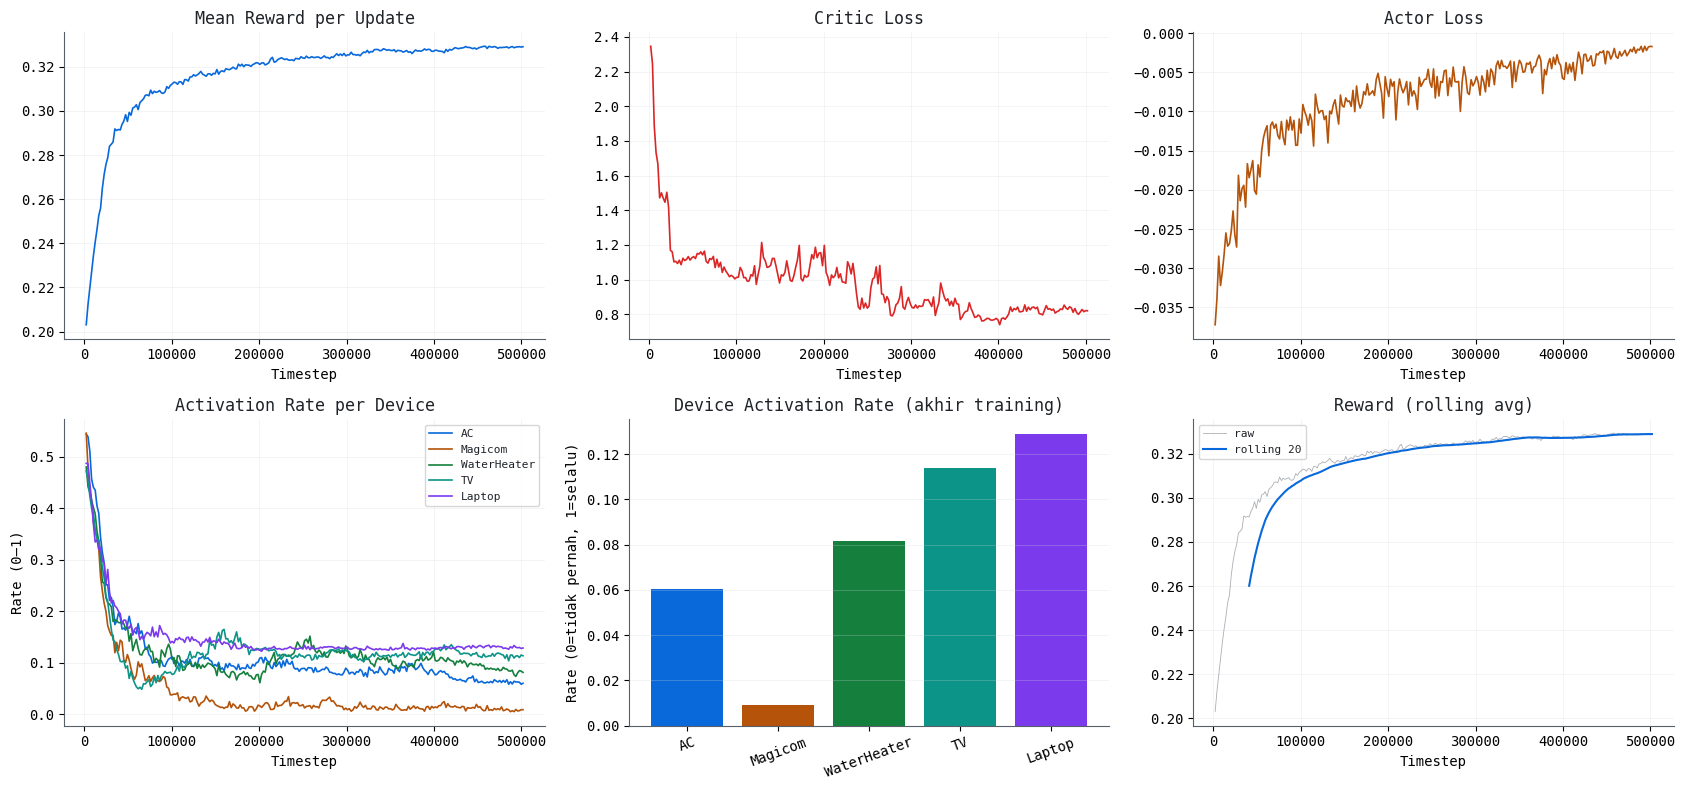

💾 Disimpan ke rl_v12_output/training_curve_v12.png


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8), facecolor="white")
axes = axes.flatten()

axes[0].plot(log["ts"], log["reward"],      color=C["blue"],   lw=1.2)
axes[0].set_title("Mean Reward per Update"); axes[0].set_xlabel("Timestep"); axes[0].grid(alpha=0.3)

axes[1].plot(log["ts"], log["critic_loss"],  color=C["red"],    lw=1.2)
axes[1].set_title("Critic Loss"); axes[1].set_xlabel("Timestep"); axes[1].grid(alpha=0.3)

axes[2].plot(log["ts"], log["actor_loss"],   color=C["amber"],  lw=1.2)
axes[2].set_title("Actor Loss"); axes[2].set_xlabel("Timestep"); axes[2].grid(alpha=0.3)

# Rate aktivasi per device sepanjang training
colors_dev = [C["blue"],C["amber"],C["green"],C["teal"],C["purple"]]
for i, name in enumerate(DEVICE_NAMES):
    rates = [d[name] for d in log["device_rate"]]
    axes[3].plot(log["ts"], rates, color=colors_dev[i], lw=1.2, label=name)
axes[3].set_title("Activation Rate per Device"); axes[3].set_xlabel("Timestep")
axes[3].set_ylabel("Rate (0–1)"); axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

# Final device rate (bar)
final_rates = [log["device_rate"][-1][n] for n in DEVICE_NAMES]
axes[4].bar(DEVICE_NAMES, final_rates, color=colors_dev)
axes[4].set_title("Device Activation Rate (akhir training)")
axes[4].set_ylabel("Rate (0=tidak pernah, 1=selalu)")
axes[4].tick_params(axis='x', rotation=20); axes[4].grid(axis='y', alpha=0.3)

# Rolling reward
w = min(20, len(log["reward"]))
roll = pd.Series(log["reward"]).rolling(w).mean()
axes[5].plot(log["ts"], log["reward"], color=C["gray"], lw=0.6, alpha=0.5, label="raw")
axes[5].plot(log["ts"], roll,          color=C["blue"], lw=1.5, label=f"rolling {w}")
axes[5].set_title("Reward (rolling avg)"); axes[5].set_xlabel("Timestep")
axes[5].legend(fontsize=8); axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "training_curve_v12.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Disimpan ke rl_v12_output/training_curve_v12.png")


## Cell 10 — Validasi

📊 HASIL VALIDASI v12
   Steps         : 7735
   Mean reward   : -0.1527
   Mean daya     : 63.2W
   Mean pred_watt: 70.6W
   Mean eff_red  : 5.2%

   Activation rate per device:
     AC            : 10.2%  (789 dari 7735 langkah)
     Magicom       : 0.0%  (0 dari 7735 langkah)
     WaterHeater   : 4.5%  (347 dari 7735 langkah)
     TV            : 13.7%  (1062 dari 7735 langkah)
     Laptop        : 11.6%  (894 dari 7735 langkah)


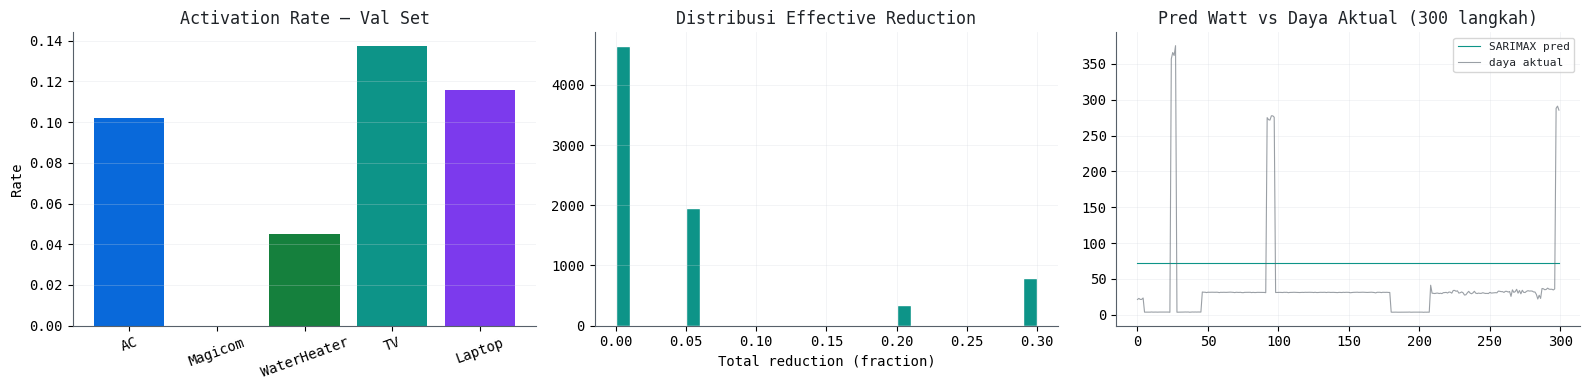

✅ pred_watt OK


In [33]:
actor.eval()
env_val = BudgetEnergyEnvV12(val_rows, budget=DEFAULT_BUDGET)

val_actions_all = []  # list of [N_DEVICES] lists
val_rewards, val_effective_red, val_daya, val_preds = [], [], [], []

s = env_val.reset(); done = False
while not done:
    t = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        acts = actor.greedy_action(t)               # deterministic, [1, N_DEVICES]
    a_list = acts.squeeze(0).cpu().numpy().tolist()
    ns, r, done, info = env_val.step(a_list)
    val_actions_all.append(a_list)
    val_rewards.append(r)
    val_effective_red.append(info["total_red"])
    val_daya.append(float(s[0]) * DAYA_MAX)
    val_preds.append(float(s[13]) * WATT_MAX)
    s = ns

val_arr = np.array(val_actions_all)  # [N_val, N_DEVICES]

print("📊 HASIL VALIDASI v12")
print(f"   Steps         : {len(val_rewards)}")
print(f"   Mean reward   : {np.mean(val_rewards):+.4f}")
print(f"   Mean daya     : {np.mean(val_daya):.1f}W")
print(f"   Mean pred_watt: {np.mean(val_preds):.1f}W")
print(f"   Mean eff_red  : {np.mean(val_effective_red)*100:.1f}%")
print()
print("   Activation rate per device:")
for i, name in enumerate(DEVICE_NAMES):
    rate = val_arr[:, i].mean()
    print(f"     {name:<14}: {rate*100:.1f}%  ({int(rate*len(val_rewards))} dari {len(val_rewards)} langkah)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor="white")

# Define colors_dev locally for this cell
colors_dev = [C["blue"],C["amber"],C["green"],C["teal"],C["purple"]]

axes[0].bar(DEVICE_NAMES, [val_arr[:, i].mean() for i in range(N_DEVICES)],
            color=colors_dev)
axes[0].set_title("Activation Rate — Val Set")
axes[0].set_ylabel("Rate"); axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(val_effective_red, bins=30, color=C["teal"], edgecolor="white")
axes[1].set_title("Distribusi Effective Reduction")
axes[1].set_xlabel("Total reduction (fraction)"); axes[1].grid(alpha=0.3)

axes[2].plot(val_preds[:300], color=C["teal"],  lw=0.8, label="SARIMAX pred")
axes[2].plot(val_daya[:300],  color=C["gray"],  lw=0.8, alpha=0.6, label="daya aktual")
axes[2].set_title("Pred Watt vs Daya Aktual (300 langkah)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "validation_v12.png", dpi=120, bbox_inches="tight")
plt.show()

if np.mean(val_preds) < 1.0:
    print("⚠️  pred_watt mendekati 0 — cek Cell 3 (SARIMAX_FORECAST_MAP)")
else:
    print("✅ pred_watt OK")

## Cell 11 — Debug log_konfirmasi (opsional)

In [34]:
# Cek kenapa 130 entri log_konfirmasi tidak ter-parse
lk = RAW_DATA.get("log_konfirmasi", {})
no_ts, bad_ts, ok = 0, 0, 0

for k, v in lk.items():
    if not isinstance(v, dict):
        continue
    ts = v.get("timestamp") or v.get("waktu")
    if ts is None:
        no_ts += 1
        print(f"  [no_ts]  key={k}  fields={list(v.keys())}")
        if no_ts >= 5:
            print("  ... (truncated)")
            break
    else:
        try:
            pd.Timestamp(int(ts), unit="ms", tz="UTC")
            ok += 1
        except:
            bad_ts += 1
            print(f"  [bad_ts] key={k}  ts={ts}")

print(f"\nRingkasan:")
print(f"  OK          : {ok}")
print(f"  No timestamp: {no_ts}")
print(f"  Bad timestamp: {bad_ts}")

  [bad_ts] key=-Oo_J1GKi-fN6JJtuEci  ts=2026-03-25T14:05:01.963Z
  [bad_ts] key=-Oo_MyI5C8pNLbBl39Nr  ts=2026-03-25T14:22:14.378Z
  [bad_ts] key=-Oobbqo25YFURsN8LyWv  ts=2026-03-26T00:50:52.856Z
  [bad_ts] key=-Ooe3zhoBsUqJ-12BvrG  ts=2026-03-26T12:17:25.474Z
  [bad_ts] key=-OoiAU-4yPzo8IAV2ZQl  ts=2026-03-27T07:24:16.076Z
  [bad_ts] key=-Ooiu4zMQ2benHZM3jpg  ts=2026-03-27T10:47:54.728Z
  [bad_ts] key=-Ooiu5sVygQ0ApbbCJp2  ts=2026-03-27T10:47:58.392Z
  [bad_ts] key=-OoluoQId6vs7AEsjfj4  ts=2026-03-28T00:49:56.406Z
  [bad_ts] key=-OomkYSpf14XcAcRrpX6  ts=2026-03-28T04:44:42.745Z
  [bad_ts] key=-OonrWLGGCNvi-OS6H0O  ts=2026-03-28T09:54:45.002Z
  [bad_ts] key=-OopOpWiE4ZG7mPqamE6  ts=2026-03-28T17:04:16.980Z
  [bad_ts] key=-OopdKvkq44cKWP8jnLT  ts=2026-03-28T18:12:01.879Z
  [bad_ts] key=-OopxWW8eD0359tmGnbW  ts=2026-03-28T19:40:13.747Z
  [bad_ts] key=-OosjcGMtOA_-HSTA9IS  ts=2026-03-29T08:38:22.669Z
  [bad_ts] key=-Ootrce2tT0BoS6yjitr  ts=2026-03-29T13:52:59.796Z
  [bad_ts] key=-OoueSsMzq

## Cell 12 — Simpan Model

In [35]:
torch.save({
    "actor":            actor.state_dict(),
    "version":          "v12",
    "obs_dim":          OBS_DIM,
    "hidden_dim":       HIDDEN_DIM,
    "n_devices":        N_DEVICES,
    "device_names":     DEVICE_NAMES,
    "device_reduction": DEVICE_REDUCTION,
    "device_watt_min":  DEVICE_WATT_MIN,
    "device_watt_max":  DEVICE_WATT_MAX,
    "tarif_kwh":        TARIF_KWH,
    "budget":           DEFAULT_BUDGET,
    "training_ts":      TOTAL_TS,
    "mean_reward":      float(np.mean(log["reward"][-10:])),
    "final_dev_rate":   log["device_rate"][-1],
    "saved_at":         datetime.now(TZ).strftime("%Y-%m-%d %H:%M:%S"),
}, MODEL_SAVE)

print(f"✅ Model v12 disimpan ke: {MODEL_SAVE}")
print(f"   version          = v12")
print(f"   obs_dim          = {OBS_DIM}")
print(f"   n_devices        = {N_DEVICES} ({DEVICE_NAMES})")
print(f"   mean_reward      = {float(np.mean(log['reward'][-10:])):+.4f}")
print(f"   final dev rate   = {log['device_rate'][-1]}")
print()
print("   ⚠️  Update pekerja_ai.py untuk load model v12:")
print("     ckpt = torch.load(...)")
print("     actor = MultiDiscreteActor(ckpt['obs_dim'], ckpt['hidden_dim'], ckpt['n_devices'])")
print("     actor.load_state_dict(ckpt['actor'])")
print("     actions = actor.greedy_action(state_tensor)  # returns [1, N_DEVICES]")


✅ Model v12 disimpan ke: /content/drive/MyDrive/data/actor_rl_v12.pt
   version          = v12
   obs_dim          = 16
   n_devices        = 5 (['AC', 'Magicom', 'WaterHeater', 'TV', 'Laptop'])
   mean_reward      = +0.3289
   final dev rate   = {'AC': 0.060546875, 'Magicom': 0.00927734375, 'WaterHeater': 0.08154296875, 'TV': 0.11376953125, 'Laptop': 0.12890625}

   ⚠️  Update pekerja_ai.py untuk load model v12:
     ckpt = torch.load(...)
     actor = MultiDiscreteActor(ckpt['obs_dim'], ckpt['hidden_dim'], ckpt['n_devices'])
     actor.load_state_dict(ckpt['actor'])
     actions = actor.greedy_action(state_tensor)  # returns [1, N_DEVICES]


## Cell 13 — Evaluasi Akurasi Komprehensif

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10b — EVALUASI AKURASI KOMPREHENSIF
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import precision_score, recall_score, f1_score
import warnings; warnings.filterwarnings("ignore")

print("=" * 55)
print("  EVALUASI AKURASI MODEL RL v12")
print("=" * 55)

# ── 1. AKURASI DEVICE ACTIVATION (Precision / Recall / F1) ───────────────────
# Mengukur: saat agent tekan tombol device X, seberapa sering device itu memang nyala?
print("\n[1] AKURASI DEVICE ACTIVATION (vs flag aktual)\n")
print(f"  {'Device':<14} {'Precision':>10} {'Recall':>8} {'F1':>8}  Interpretasi")
print(f"  {'-'*14} {'-'*10} {'-'*8} {'-'*8}  {'-'*30}")

# Kumpulkan flags aktual selama validasi
actor.eval()
env_val2 = BudgetEnergyEnvV12(val_rows, budget=DEFAULT_BUDGET)
s = env_val2.reset(); done = False

y_true_per_dev = [[] for _ in range(N_DEVICES)]  # flag aktual
y_pred_per_dev = [[] for _ in range(N_DEVICES)]  # aksi agent
eff_reds, gaps_before, gaps_after = [], [], []

while not done:
    t    = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)
    row  = val_rows[env_val2.i]
    with torch.no_grad():
        acts = actor.greedy_action(t)
    a_list = acts.squeeze(0).cpu().numpy().tolist()
    flags  = BudgetEnergyEnvV12._device_flags(row)

    for i in range(N_DEVICES):
        y_true_per_dev[i].append(flags[i])
        y_pred_per_dev[i].append(a_list[i])

    ns, r, done, info = env_val2.step(a_list)
    eff_reds.append(info["total_red"])
    gaps_before.append(info["gap_before"])
    gaps_after.append(info["gap_after"])
    s = ns

for i, name in enumerate(DEVICE_NAMES):
    yt = y_true_per_dev[i]
    yp = y_pred_per_dev[i]
    if sum(yp) == 0:
        print(f"  {name:<14} {'N/A':>10} {'N/A':>8} {'N/A':>8}  agent tidak pernah aktifkan")
        continue
    pr = precision_score(yt, yp, zero_division=0)
    rc = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)

    if pr >= 0.6:   interp = "✅ Presisi tinggi"
    elif pr >= 0.3: interp = "⚠️  Sering salah aktif"
    else:           interp = "❌ Mostly salah aktif"

    print(f"  {name:<14} {pr:>9.1%} {rc:>8.1%} {f1:>8.3f}  {interp}")

print("""
  Precision = dari semua langkah agent aktifkan device X,
              berapa % device X memang nyala (flag=1)?
  Recall    = dari semua langkah device X nyala,
              berapa % agent berhasil mendeteksi & aktifkan?
  F1        = keseimbangan precision dan recall (0–1)
""")

# ── 2. BUDGET COMPLIANCE RATE ─────────────────────────────────────────────────
print("[2] BUDGET COMPLIANCE RATE\n")
n_comply    = sum(1 for g in gaps_after if g <= 0)
n_total     = len(gaps_after)
comply_rate = n_comply / n_total

print(f"  Langkah di bawah budget setelah reduksi : {n_comply:,}/{n_total:,} ({comply_rate:.1%})")
print(f"  Rata-rata gap sebelum reduksi           : Rp {np.mean(gaps_before):+,.0f}/bulan")
print(f"  Rata-rata gap setelah reduksi           : Rp {np.mean(gaps_after):+,.0f}/bulan")
print(f"  Rata-rata pengurangan gap               : Rp {np.mean(gaps_before)-np.mean(gaps_after):,.0f}/bulan")
if comply_rate >= 0.5:
    print(f"\n  ✅ Agent berhasil menjaga >50% langkah di bawah budget")
else:
    print(f"\n  ⚠️  Data tidak memungkinkan compliance tinggi (pred_watt > budget)")

# ── 3. SARIMAX PREDICTION ACCURACY ───────────────────────────────────────────
print("\n[3] AKURASI SARIMAX FORECAST (vs daya aktual)\n")
actuals = np.array([r.daya for r in val_rows[:len(eff_reds)]])
preds   = np.array([r.sarimax_pred if r.sarimax_pred > 0 else r.daya
                    for r in val_rows[:len(eff_reds)]])
mask    = actuals > 5  # filter noise saat daya sangat rendah
mae     = np.mean(np.abs(preds[mask] - actuals[mask]))
mape    = np.mean(np.abs(preds[mask] - actuals[mask]) / actuals[mask]) * 100
rmse    = np.sqrt(np.mean((preds[mask] - actuals[mask])**2))
corr    = np.corrcoef(preds[mask], actuals[mask])[0, 1]

print(f"  MAE   : {mae:.1f} W       (rata-rata selisih prediksi vs aktual)")
print(f"  MAPE  : {mape:.1f}%       (rata-rata error dalam persen)")
print(f"  RMSE  : {rmse:.1f} W       (sensitif terhadap outlier)")
print(f"  Corr  : {corr:.3f}        (0=tidak korelasi, 1=sempurna)")

if mape < 20:   print(f"\n  ✅ SARIMAX akurat (MAPE < 20%)")
elif mape < 40: print(f"\n  ⚠️  SARIMAX cukup (MAPE 20-40%)")
else:           print(f"\n  ❌ SARIMAX kurang akurat (MAPE > 40%) — pertimbangkan retrain")

# ── 4. POLICY EFFICIENCY ─────────────────────────────────────────────────────
print("\n[4] POLICY EFFICIENCY\n")
# Theoretical max: selalu aktifkan device yang flag=1
theo_reds = []
for i_row, row in enumerate(val_rows[:len(eff_reds)]):
    flags    = BudgetEnergyEnvV12._device_flags(row)
    theo_red = sum(DEVICE_REDUCTION[i] for i in range(N_DEVICES) if flags[i] == 1)
    theo_reds.append(theo_red)

actual_mean = np.mean(eff_reds)
theo_mean   = np.mean(theo_reds)
efficiency  = actual_mean / theo_mean if theo_mean > 0 else 0

print(f"  Reduksi aktual (agent)     : {actual_mean*100:.1f}%")
print(f"  Reduksi teoritis maksimum  : {theo_mean*100:.1f}%")
print(f"  Policy efficiency          : {efficiency:.1%}")

if efficiency >= 0.8:   print(f"\n  ✅ Agent mencapai >80% dari potensi maksimum")
elif efficiency >= 0.5: print(f"\n  ⚠️  Agent mencapai 50-80% dari potensi")
else:                   print(f"\n  ❌ Agent di bawah 50% potensi — cek reward shaping")

print("\n" + "=" * 55)

  EVALUASI AKURASI MODEL RL v12

[1] AKURASI DEVICE ACTIVATION (vs flag aktual)

  Device          Precision   Recall       F1  Interpretasi
  -------------- ---------- -------- --------  ------------------------------
  AC                100.0%   100.0%    1.000  ✅ Presisi tinggi
  Magicom               N/A      N/A      N/A  agent tidak pernah aktifkan
  WaterHeater       100.0%   100.0%    1.000  ✅ Presisi tinggi
  TV                100.0%   100.0%    1.000  ✅ Presisi tinggi
  Laptop            100.0%   100.0%    1.000  ✅ Presisi tinggi

  Precision = dari semua langkah agent aktifkan device X,
              berapa % device X memang nyala (flag=1)?
  Recall    = dari semua langkah device X nyala,
              berapa % agent berhasil mendeteksi & aktifkan?
  F1        = keseimbangan precision dan recall (0–1)

[2] BUDGET COMPLIANCE RATE

  Langkah di bawah budget setelah reduksi : 1,136/7,735 (14.7%)
  Rata-rata gap sebelum reduksi           : Rp +6,234/bulan
  Rata-rata gap setelah

## Cell 14 — Evaluasi Akurasi SARIMAX (Harian)

In [37]:
import pytz
import numpy as np
import pandas as pd

# ── 3. AKURASI SARIMAX FORECAST (evaluasi level HARIAN) ──────────────────────
print("\n[3] AKURASI SARIMAX FORECAST (vs konsumsi harian aktual)\n")

# Rekonstruksi tanggal dari val_rows
_recs2 = [dict(v, _key=k) for k, v in RAW_DATA["history"].items() if isinstance(v, dict)]
_df2   = pd.DataFrame(_recs2)
_wk2   = pd.to_numeric(_df2.get("waktu", pd.Series([None]*len(_df2))), errors="coerce")
_df2["dt"] = pd.to_datetime(_wk2, unit="ms", errors="coerce").dt.tz_localize("UTC").dt.tz_convert(TIMEZONE)
_df2 = _df2.dropna(subset=["dt","Daya"]).sort_values("dt")
_df2["Daya"] = pd.to_numeric(_df2["Daya"], errors="coerce")

_val_df2 = _df2.tail(len(val_rows)).copy()
_val_df2["sarimax"] = [r.sarimax_pred if r.sarimax_pred > 0 else r.daya for r in val_rows]
_val_df2["date"]    = _val_df2["dt"].dt.date

# Agregasi harian: rata-rata watt → kWh/hari
_daily = _val_df2.groupby("date").agg(
    aktual_kwh=("Daya",    lambda x: x.mean() * 24 / 1000),
    pred_kwh  =("sarimax", lambda x: x.mean() * 24 / 1000)
).reset_index()

# Filter dasar (data tidak kosong)
_daily_valid = _daily[_daily["aktual_kwh"] > 0.05].copy()

# Filter tambahan: Hari aktif saja (aktual >= 0.5 kWh)
THRESHOLD_AKTIF = 0.5
_daily_active = _daily_valid[_daily_valid["aktual_kwh"] >= THRESHOLD_AKTIF].copy()

if not _daily_valid.empty:
    mae_d  = np.mean(np.abs(_daily_valid["pred_kwh"] - _daily_valid["aktual_kwh"]))
    mape_d = np.mean(np.abs(_daily_valid["pred_kwh"] - _daily_valid["aktual_kwh"]) / _daily_valid["aktual_kwh"]) * 100

    print(f"  Jumlah hari evaluasi (total) : {len(_daily_valid)} hari")
    print(f"  MAE (Semua)   : {mae_d:.3f} kWh/hari")
    print(f"  MAPE (Semua)  : {mape_d:.1f}%")

if not _daily_active.empty:
    mae_f  = np.mean(np.abs(_daily_active["pred_kwh"] - _daily_active["aktual_kwh"]))
    mape_f = np.mean(np.abs(_daily_active["pred_kwh"] - _daily_active["aktual_kwh"]) / _daily_active["aktual_kwh"]) * 100
    print(f"  \n  --- Filter Hari Aktif (>= {THRESHOLD_AKTIF} kWh) ---")
    print(f"  Jumlah hari  : {len(_daily_active)} hari")
    print(f"  MAE Aktif    : {mae_f:.3f} kWh/hari")
    print(f"  MAPE Aktif   : {mape_f:.1f}%  <-- Lebih representatif")

# Tabel per hari
print(f"\n  {'Tanggal':<12} {'Aktual':>10} {'Pred':>10} {'Error':>8}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*8}")
for _, row_d in _daily_valid.iterrows():
    err = abs(row_d["pred_kwh"] - row_d["aktual_kwh"]) / row_d["aktual_kwh"] * 100
    flag = "!" if err > 30 else ""
    tag = "[AKTIF]" if row_d["aktual_kwh"] >= THRESHOLD_AKTIF else "[LOW]"
    print(f"  {str(row_d['date']):<12} {row_d['aktual_kwh']:>8.3f} kWh {row_d['pred_kwh']:>8.3f} kWh  {err:>5.1f}%  {flag} {tag}")


[3] AKURASI SARIMAX FORECAST (vs konsumsi harian aktual)

  Jumlah hari evaluasi (total) : 11 hari
  MAE (Semua)   : 1.240 kWh/hari
  MAPE (Semua)  : 225.3%
  
  --- Filter Hari Aktif (>= 0.5 kWh) ---
  Jumlah hari  : 8 hari
  MAE Aktif    : 1.182 kWh/hari
  MAPE Aktif   : 61.0%  <-- Lebih representatif

  Tanggal          Aktual       Pred    Error
  ------------ ---------- ---------- --------
  2026-04-13      2.487 kWh    1.741 kWh   30.0%   [AKTIF]
  2026-04-14      1.219 kWh    1.733 kWh   42.2%  ! [AKTIF]
  2026-04-15      0.428 kWh    1.727 kWh  303.6%  ! [LOW]
  2026-04-16      1.234 kWh    1.726 kWh   39.9%  ! [AKTIF]
  2026-04-17      1.684 kWh    1.724 kWh    2.4%   [AKTIF]
  2026-04-18      2.434 kWh    1.633 kWh   32.9%  ! [AKTIF]
  2026-04-19      3.918 kWh    1.633 kWh   58.3%  ! [AKTIF]
  2026-04-20      5.098 kWh    1.633 kWh   68.0%  ! [AKTIF]
  2026-04-29      0.254 kWh    1.633 kWh  541.9%  ! [LOW]
  2026-05-09      0.519 kWh    1.633 kWh  214.5%  ! [AKTIF]
  2026-

In [38]:
actor.eval()
critic.eval()
env_test = BudgetEnergyEnvV12(val_rows[:100], budget=DEFAULT_BUDGET)
s = env_test.reset()

val_values = []
done = False
while not done:
    t = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        v = critic(t)
    val_values.append(float(v.item()))
    acts   = actor.greedy_action(t)
    a_list = acts.squeeze(0).cpu().numpy().tolist()
    s, _, done, _ = env_test.step(a_list)

print(f"V(s) Statistics (Sample n=100):")
print(f"  Mean  : {np.mean(val_values):.4f}")
print(f"  Min   : {np.min(val_values):.4f}  (Worst state)")
print(f"  Max   : {np.max(val_values):.4f}  (Best state)")
print(f"  Std   : {np.std(val_values):.4f}")

V(s) Statistics (Sample n=100):
  Mean  : 31.8665
  Min   : 30.5695  (Worst state)
  Max   : 32.8880  (Best state)
  Std   : 1.0046


In [39]:
# ── CELL BARU: inspeksi actor & critic per state ──────────────────────────────
actor.eval(); critic.eval()

# Ambil 3 state tipikal dari val_rows
sample_indices = [0, len(val_rows)//2, -1]
labels = ["awal (daya rendah)", "tengah", "akhir"]

for idx, label in zip(sample_indices, labels):
    row = val_rows[idx]
    s   = BudgetEnergyEnvV12(val_rows, DEFAULT_BUDGET)._state(row)
    t   = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        v     = critic(t)
        dists = actor._get_dists(t)

    print(f"\n{'='*52}")
    print(f"State: {label}")
    print(f"  Daya aktual : {row.daya:.1f}W")
    print(f"  Suhu        : {row.suhu:.1f}°C")
    print(f"  Jam         : {int(row.jam):02d}:00")
    print(f"  SARIMAX pred: {row.sarimax_pred:.1f}W")
    print(f"\n  V(s) = {v.item():.4f}  ← estimasi return ke depan")
    print(f"\n  {'Device':<14} {'P(jaga)':>9} {'P(kurangi)':>11} {'Aksi':>8}")
    print(f"  {'-'*46}")
    for i, (name, dist) in enumerate(zip(DEVICE_NAMES, dists)):
        p0 = dist.probs[0, 0].item()
        p1 = dist.probs[0, 1].item()
        aksi = "KURANGI ✓" if p1 > 0.5 else "jaga"
        print(f"  {name:<14} {p0:>8.1%} {p1:>10.1%} {aksi:>8}")


State: awal (daya rendah)
  Daya aktual : 21.3W
  Suhu        : 29.0°C
  Jam         : 10:00
  SARIMAX pred: 72.5W

  V(s) = 30.5709  ← estimasi return ke depan

  Device           P(jaga)  P(kurangi)     Aksi
  ----------------------------------------------
  AC                98.8%       1.2%     jaga
  Magicom           97.7%       2.3%     jaga
  WaterHeater       98.7%       1.3%     jaga
  TV                99.2%       0.8%     jaga
  Laptop             0.4%      99.6% KURANGI ✓

State: tengah
  Daya aktual : 3.8W
  Suhu        : 28.6°C
  Jam         : 05:00
  SARIMAX pred: 71.9W

  V(s) = 30.3873  ← estimasi return ke depan

  Device           P(jaga)  P(kurangi)     Aksi
  ----------------------------------------------
  AC                99.9%       0.1%     jaga
  Magicom           99.5%       0.5%     jaga
  WaterHeater       98.7%       1.3%     jaga
  TV                99.5%       0.5%     jaga
  Laptop            99.0%       1.0%     jaga

State: akhir
  Daya aktual : 27